In [1]:
import os, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

In [3]:
BASE_DIR = r"C:\Users\oussa\Desktop\la cite S2\Outils infonuagiques\UA3\projet\dataset-resized"
categories = os.listdir(BASE_DIR)
data = []
for cat in categories:
    folder = os.path.join(BASE_DIR, cat)
    images = os.listdir(folder)
    for img in images:
        data.append({'fichier': img, 'categorie': cat})
df = pd.DataFrame(data)
print(df.head())                        # Affiche les 5 premières lignes
print(df['categorie'].value_counts())   # Compte par catégorie

            fichier  categorie
0    cardboard1.jpg  cardboard
1   cardboard10.jpg  cardboard
2  cardboard100.jpg  cardboard
3  cardboard101.jpg  cardboard
4  cardboard102.jpg  cardboard
categorie
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: count, dtype: int64


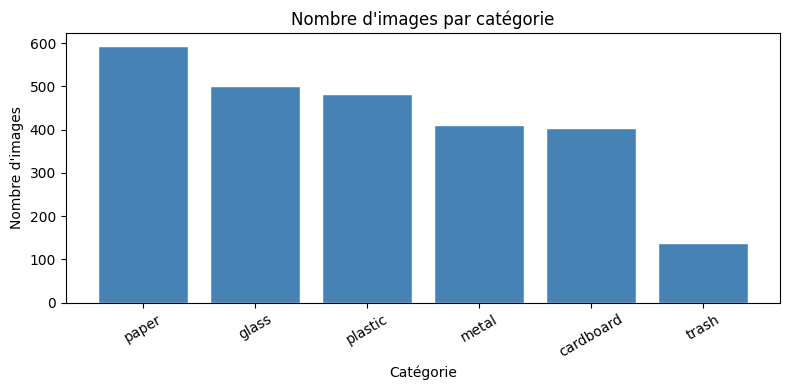

In [4]:
counts = df['categorie'].value_counts()
plt.figure(figsize=(8, 4))
plt.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
plt.title('Nombre d\'images par catégorie')
plt.xlabel('Catégorie')
plt.ylabel('Nombre d\'images')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('graphique_categories.png')
plt.show()

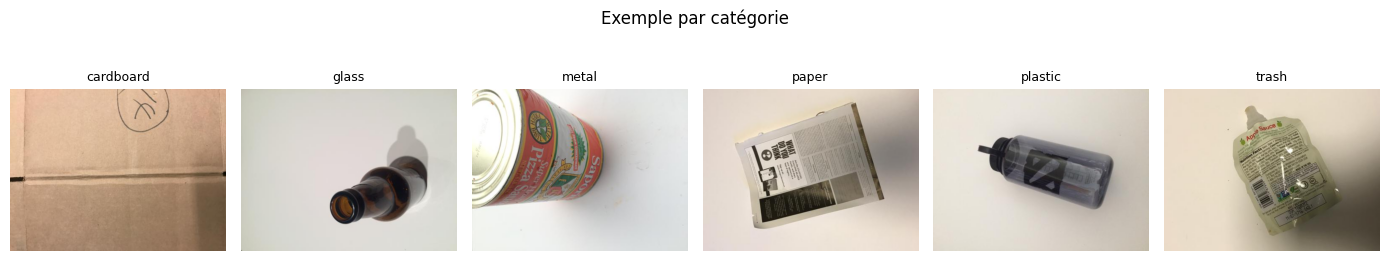

In [5]:
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i, cat in enumerate(categories):
    img_path = os.path.join(BASE_DIR, cat, os.listdir(os.path.join(BASE_DIR, cat))[0])
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cat, fontsize=9)
    axes[i].axis('off')
plt.suptitle('Exemple par catégorie', fontsize=12)
plt.tight_layout()
plt.savefig('exemples_categories.png')
plt.show()

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
sizes = set()

for cat in os.listdir(BASE_DIR):
    cat_path = os.path.join(BASE_DIR, cat)

    if not os.path.isdir(cat_path):
        continue

    for img_name in os.listdir(cat_path):
        img_path = os.path.join(cat_path, img_name)

        try:
            with Image.open(img_path) as img:
                sizes.add(img.size)
        except Exception:
            pass

print("Tailles uniques dans le dataset :", sizes)


Tailles uniques dans le dataset : {(512, 384)}


In [8]:

IMG_SIZE = (128, 128)

categories = ['cardboard','glass','metal','paper','plastic','trash']
label_map = {cat: i for i, cat in enumerate(categories)}

X, y = [], []

for cat in categories:
    folder = os.path.join(BASE_DIR, cat)

    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)

        try:
            img = Image.open(path).convert('RGB').resize(IMG_SIZE)
            X.append(np.array(img) / 255.0)
            y.append(label_map[cat])
        except Exception as e:
            print(f"Erreur avec {path} : {e}")

X = np.array(X)  # shape: (N, 128, 128, 3)
y = np.array(y)  # shape: (N,)

print(f'X: {X.shape}, y: {y.shape}')


X: (2527, 128, 128, 3), y: (2527,)


Transformer les images pour KNN

In [ ]:
#La transformation avec reshape permet de convertir chaque image en vecteur numérique afin de la rendre compatible avec le modèle KNN.

In [ ]:
X_flat = X.reshape(X.shape[0], -1)
print("Nouvelle forme de X :", X_flat.shape) 

Nouvelle forme de X : (2527, 49152)


In [ ]:
#(nombre d’échantillons, nombre de caractéristiques)

In [ ]:
#Séparation des données (Train / Test)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y,
    test_size=0.2,
    random_state=42,
    stratify=y #garder la meme proportion des classes 
)

Création du modele KNN

In [14]:
from sklearn.neighbors import KNeighborsClassifier
#intialer le model
model_knn = KNeighborsClassifier(n_neighbors=3)
#trainer le model 
model_knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
y_pred_kn=model_knn.predict(X_test)
y_pred_kn

array([4, 4, 0, 1, 1, 1, 2, 3, 2, 2, 4, 0, 3, 1, 0, 1, 0, 3, 0, 1, 1, 3,
       3, 3, 1, 1, 1, 4, 1, 4, 5, 1, 0, 3, 1, 1, 1, 1, 1, 1, 3, 1, 4, 0,
       5, 4, 1, 2, 4, 2, 0, 4, 4, 4, 3, 1, 2, 3, 2, 4, 3, 3, 0, 4, 1, 1,
       5, 4, 4, 1, 4, 1, 4, 1, 0, 0, 4, 0, 4, 0, 4, 3, 0, 0, 3, 0, 4, 4,
       4, 0, 0, 1, 1, 4, 1, 1, 3, 0, 4, 2, 0, 4, 0, 3, 3, 0, 3, 0, 5, 2,
       1, 1, 0, 5, 0, 0, 4, 1, 4, 5, 4, 1, 0, 0, 4, 4, 1, 4, 0, 1, 4, 1,
       4, 1, 1, 0, 0, 3, 3, 4, 5, 1, 5, 3, 3, 4, 4, 4, 1, 4, 1, 1, 1, 4,
       3, 5, 3, 4, 1, 2, 1, 1, 5, 0, 0, 0, 1, 0, 4, 3, 4, 0, 1, 1, 4, 2,
       2, 1, 2, 1, 0, 1, 1, 0, 3, 1, 1, 0, 4, 4, 3, 3, 4, 0, 4, 3, 0, 2,
       4, 4, 4, 1, 4, 4, 3, 1, 0, 0, 4, 0, 4, 3, 3, 1, 4, 5, 0, 1, 0, 1,
       4, 4, 3, 4, 4, 4, 0, 1, 0, 4, 4, 4, 1, 1, 4, 2, 5, 4, 4, 1, 3, 4,
       2, 1, 4, 0, 4, 0, 4, 4, 1, 1, 4, 1, 4, 1, 1, 1, 4, 0, 4, 2, 3, 5,
       1, 4, 1, 4, 3, 4, 4, 1, 3, 0, 4, 1, 3, 0, 0, 1, 5, 1, 0, 0, 0, 0,
       0, 4, 1, 2, 1, 4, 2, 1, 1, 0, 0, 1, 4, 4, 4,

In [22]:
#validation et amelioration le model 
#cross validation 

In [26]:
from sklearn.model_selection import cross_val_score
cross_val_score(KNeighborsClassifier(3),X_train,y_train,cv=5).mean() #cv=5 nbr de split (des partie) des donnees

np.float64(0.465602004644909)

In [ ]:
#La cross-validation avec (cv = 5) = 0.46 est très faible

* //choix du parametre K 

Choix du paramètre K – Validation croisée

Le modèle K-Nearest Neighbors (KNN) nécessite de choisir le paramètre K, qui représente le nombre de voisins utilisés pour prédire la classe d’une observation.

,le dataset contient 2527 observations.

Une règle empirique pour choisir une valeur initiale de K consiste à utiliser la racine carrée du nombre d’observations.

Dans notre cas :
√2527 ≈ 50

Cette valeur sert uniquement de point de départ. Ensuite, plusieurs valeurs de K ont été testées à l’aide de la validation croisée (cross-validation) avec 5 folds sur les données d’entraînement.

Pour chaque valeur de K, nous avons calculé le score moyen de validation croisée afin d’identifier la valeur donnant la meilleure performance.

La valeur de K qui donne le meilleur score moyen est retenue pour le modèle final.

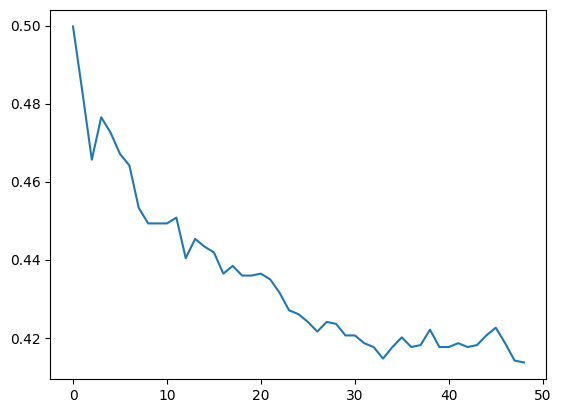

In [27]:
val_score_k=[]
for K in range(1,50):
    score=cross_val_score(KNeighborsClassifier(K),X_train,y_train,cv=5).mean()
    val_score_k.append(score)
plt.plot(val_score_k)

In [28]:
best_scor=max(val_score_k)
print("best score validation ",best_scor)
best_k = val_score_k.index(best_scor) + 1
print("best valeur de K ",best_k)

best score validation  0.4997506417308397
best valeur de K  1


In [ ]:
#Les résultats montrent que la meilleure valeur de K est 1 avec un score d’environ 0.50.
#Cependant, cette valeur peut entraîner un surapprentissage (overfitting).
#Ainsi, une valeur de K légèrement plus grande (par exemple entre 5 et 10) peut être préférable pour assurer une meilleure généralisation du modèle.

Entraîner le modèle final KNN

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [40]:
y_pred_kn = knn.predict(X_test)

In [41]:
from sklearn.model_selection import cross_val_score
cross_val_score(KNeighborsClassifier(5),X_train,y_train,cv=5).mean() #cv=5 nbr de split (des partie) des donnees

np.float64(0.4725326977142159)

In [42]:
from sklearn.metrics import accuracy_score
accuracy_kn = accuracy_score(y_test, y_pred_kn)
print("Accuracy :", accuracy_kn) 

Accuracy : 0.4525691699604743


In [43]:
#l’accuracy est 0.45 cela veut dire que le modèle classe correctement environ 45 % des images de test

Sauvegarder Le modele KNN

In [44]:
import pickle

with open("model_knn.pkl", "wb") as f:
    pickle.dump(knn, f)

Déployer le modèle dans le Cloud :La dernière étape consiste à déployer le modèle dans le Cloud afin de le rendre accessible et utilisable en ligne.